In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import wandb
import matplotlib.pyplot as plt

import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from utils.dataset import HyperGraphDataset
from metrics import LAP_loss
from train import get_config, get_model

In [3]:
config_train = "../configs/train.yaml"
config_model = "../configs/hgflow.yaml"
config_dataset = "../configs/convex_hull.yaml"
ckpt = "/storage/agrp/dreyet/Hypergraphs/hypergraphflow/convex_hull_normal_3D_30to30/k3dpvjg2/checkpoints/epoch=859-step=269180.ckpt"

config = get_config(config_train, config_model, config_dataset)

In [4]:
model = get_model(config)

if ckpt != "":
    model.load_state_dict(torch.load(ckpt)['state_dict'])

Seed set to 123456


In [5]:
ds_train = HyperGraphDataset(config['dataset'], config['dl_train']['total_size'])
ds_val   = HyperGraphDataset(config['dataset'], config['dl_val']['total_size'])
trainloader = ds_train.get_dataloader(config['dl_train'], model.name)
valloader   = ds_val.get_dataloader(config['dl_val'], model.name)

In [6]:
for example in valloader:
    x, y  = example
    break

In [7]:
x = x[0]
y = y[0]

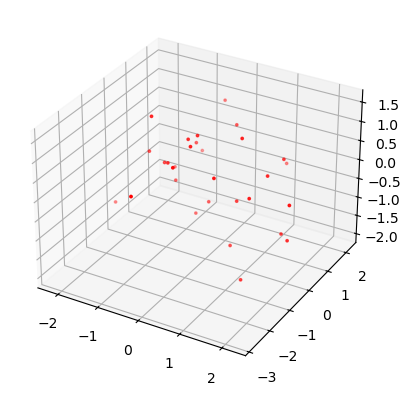

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [9]:
y[:,-1]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])

In [10]:
print("Number of hyperedges per point:")
print(y[:,:-1].sum(axis=0))
print("Number of points per hyperedge:")
print(y[:,:-1].sum(axis=1))

Number of hyperedges per point:
tensor([0., 0., 7., 0., 0., 4., 4., 0., 0., 8., 6., 4., 3., 3., 0., 6., 0., 0.,
        4., 0., 5., 6., 0., 0., 6., 0., 6., 0., 0., 0.])
Number of points per hyperedge:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])


In [11]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1)
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

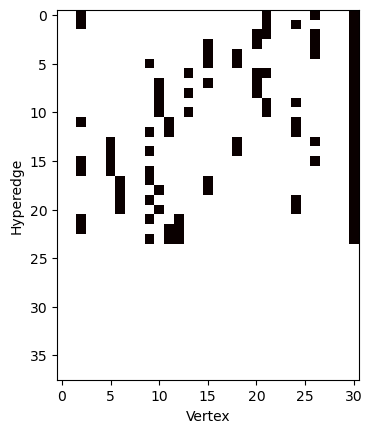

In [12]:
plot_incidence_matrix(y)

In [13]:
def align_incidence_matrix(im_pred, im_true):

    loss, indices = LAP_loss(im_pred, im_true, return_indices=True)
    indices = torch.from_numpy(indices[:,1,...])
    indices = indices.unsqueeze(-1).expand(-1, -1, im_pred.shape[2])

    im_pred_aligned = torch.gather(im_pred, 1, indices)

    return im_pred_aligned, loss, indices

In [14]:
for batch in trainloader:
    x, y = batch
    break

In [28]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

model.eval()

bs, num_edges, num_nodes = batch[1].shape

if 'refiner' in model.name:
    inputs, target = batch
    e_t, v_t, i_t = model.net.get_initial(inputs)
    seq = model.net(inputs, e_t, v_t, i_t, t_skip=model.config['iters_total']-1, t_bp=1, save_seq=True)[-1]
    aligned_seq = []
    for s in seq:
        aligned_s, _, _ = align_incidence_matrix(s, batch[1])
        aligned_seq.append(aligned_s)

    seq = torch.stack(aligned_seq, dim=0)
    pred = seq[-1]

    loss = metrics.LAP_loss(pred, target, n=min(model.config['nray'], inputs.size(0)))

elif model.FM is not None:
    im_0 = model.net.get_init_im(bs, num_edges, num_nodes, device=batch[1].device)
    seq = model.sample(im_0, batch[0], save_seq=True, num_steps=9) #, method='euler')
    im_pred = seq[-1]
    im_pred, loss, indices = model.align_incidence_matrix(im_pred, batch[1])
    seq = torch.stack([model.align_incidence_matrix(s, batch[1])[0] for s in seq])

else:
    raise NotImplementedError()

/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


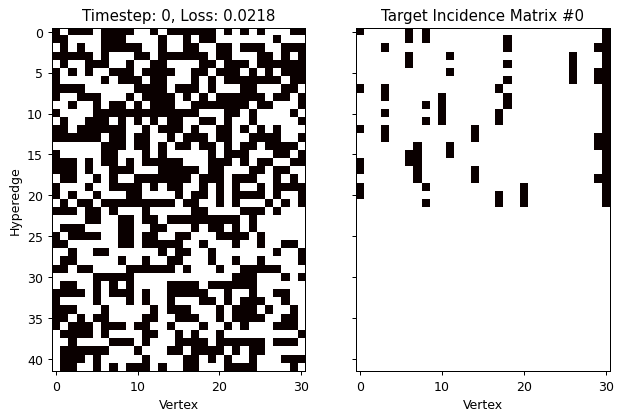

In [29]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharey=True, dpi=90)

idx = 0
to_binary = True

def update(timestep):
    ax[0].clear()
    im_pred = seq[timestep][idx]
    if to_binary:
        im_pred = convert_to_binary(im_pred, 0.5)
    im_pred = im_pred.cpu().detach().numpy()
    ax[0].imshow(1 - im_pred, cmap='hot', vmin=0, vmax=1)
    ax[0].set_title(f"Timestep: {timestep}, Loss: {loss[idx].mean():.4f}")
    ax[0].set_ylabel("Hyperedge")
    ax[0].set_xlabel("Vertex")

    ax[1].clear()
    im_true = batch[1][idx].cpu().detach().numpy()
    ax[1].imshow(1 - im_true, cmap='hot', vmin=0, vmax=1) 
    ax[1].set_title("Target Incidence Matrix #{}".format(idx))
    # ax[1].set_ylabel("Hyperedge")
    ax[1].set_xlabel("Vertex")
    # plt.tight_layout()

ani = FuncAnimation(fig, update, frames=seq.shape[0], interval=500)

# Convert the animation to HTML
HTML(ani.to_jshtml())